# Retail Sales Prediction: EDA and Feature Inspection

This notebook covers the loading, cleaning, exploratory visuals, and feature inspection workflow for the retail sales prediction project.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Image, display

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.config import (
    BEST_MODEL_PATH,
    DATA_DICTIONARY,
    FIGURES_DIR,
    PROCESSED_DATA_PATH,
    RANDOM_STATE,
    RAW_DATA_PATH,
    TARGET,
)
from src.data_loader import (
    basic_cleaning,
    load_raw_data,
    missing_value_report,
    restore_placeholders_to_null,
    save_processed_snapshot,
    summarize_numeric_columns,
)
from src.evaluation import evaluate_regression_model
from src.modeling import (
    build_linear_regression_pipeline,
    build_random_forest_pipeline,
    make_train_test_split,
    split_features_target,
    tune_random_forest,
)
from src.preprocessing import make_preprocessor
from src.visualization import (
    plot_correlation_heatmap,
    plot_linear_regression_coefficients,
    plot_model_comparison,
    plot_outlet_type_vs_sales,
    plot_rf_feature_importance,
    save_figure,
    set_plot_style,
)

pd.set_option("display.max_columns", 100)
set_plot_style()

## Loading Data

In [2]:
df = pd.read_csv(RAW_DATA_PATH)
df.info()
display(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


## Data Cleaning

In [3]:
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}")
display(df.dtypes.to_frame("dtype"))

Rows: 8,523
Columns: 12


,dtype
Item_Identifier,object
Item_Weight,float64
Item_Fat_Content,object
Item_Visibility,float64
Item_Type,object
Item_MRP,float64
Outlet_Identifier,object
Outlet_Establishment_Year,int64
Outlet_Size,object
Outlet_Location_Type,object


In [4]:
print(f"Duplicate rows: {df.duplicated().sum():,}")
display(missing_value_report(df))

Duplicate rows: 0


,missing_count,missing_percent
Outlet_Size,2410,28.28
Item_Weight,1463,17.17


In [5]:
print("Original Item_Fat_Content values:")
print(sorted(df["Item_Fat_Content"].dropna().unique()))

clean_df = basic_cleaning(df, fill_placeholders=False)

print("\nCleaned Item_Fat_Content values:")
print(sorted(clean_df["Item_Fat_Content"].dropna().unique()))

Original Item_Fat_Content values:
['LF', 'Low Fat', 'Regular', 'low fat', 'reg']



Cleaned Item_Fat_Content values:
['Low Fat', 'Regular']


In [6]:
placeholder_df = basic_cleaning(df, fill_placeholders=True)
display(placeholder_df.isna().sum().to_frame("missing_after_placeholder"))
display(summarize_numeric_columns(clean_df))

save_processed_snapshot(clean_df, PROCESSED_DATA_PATH)
print(f"Saved cleaned snapshot to: {PROCESSED_DATA_PATH}")

,missing_after_placeholder
Item_Identifier,0
Item_Weight,0
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,0
Outlet_Location_Type,0


,min,max,mean
Item_Weight,4.555,21.350,12.858
Item_Visibility,0.000,0.328,0.066
Item_MRP,31.290,266.888,140.993
Outlet_Establishment_Year,1985.000,2009.000,1997.832
Item_Outlet_Sales,33.290,13086.965,2181.289


Saved cleaned snapshot to: C:\Users\MSI\Desktop\project\Prediction-of-Product-Sales\data\processed\cleaned_sales.csv


## Exploratory Visuals

The following visuals satisfy the EDA requirements: histograms for numeric distributions, boxplots for statistical summaries, countplots for categorical frequencies, and a heatmap for correlations.

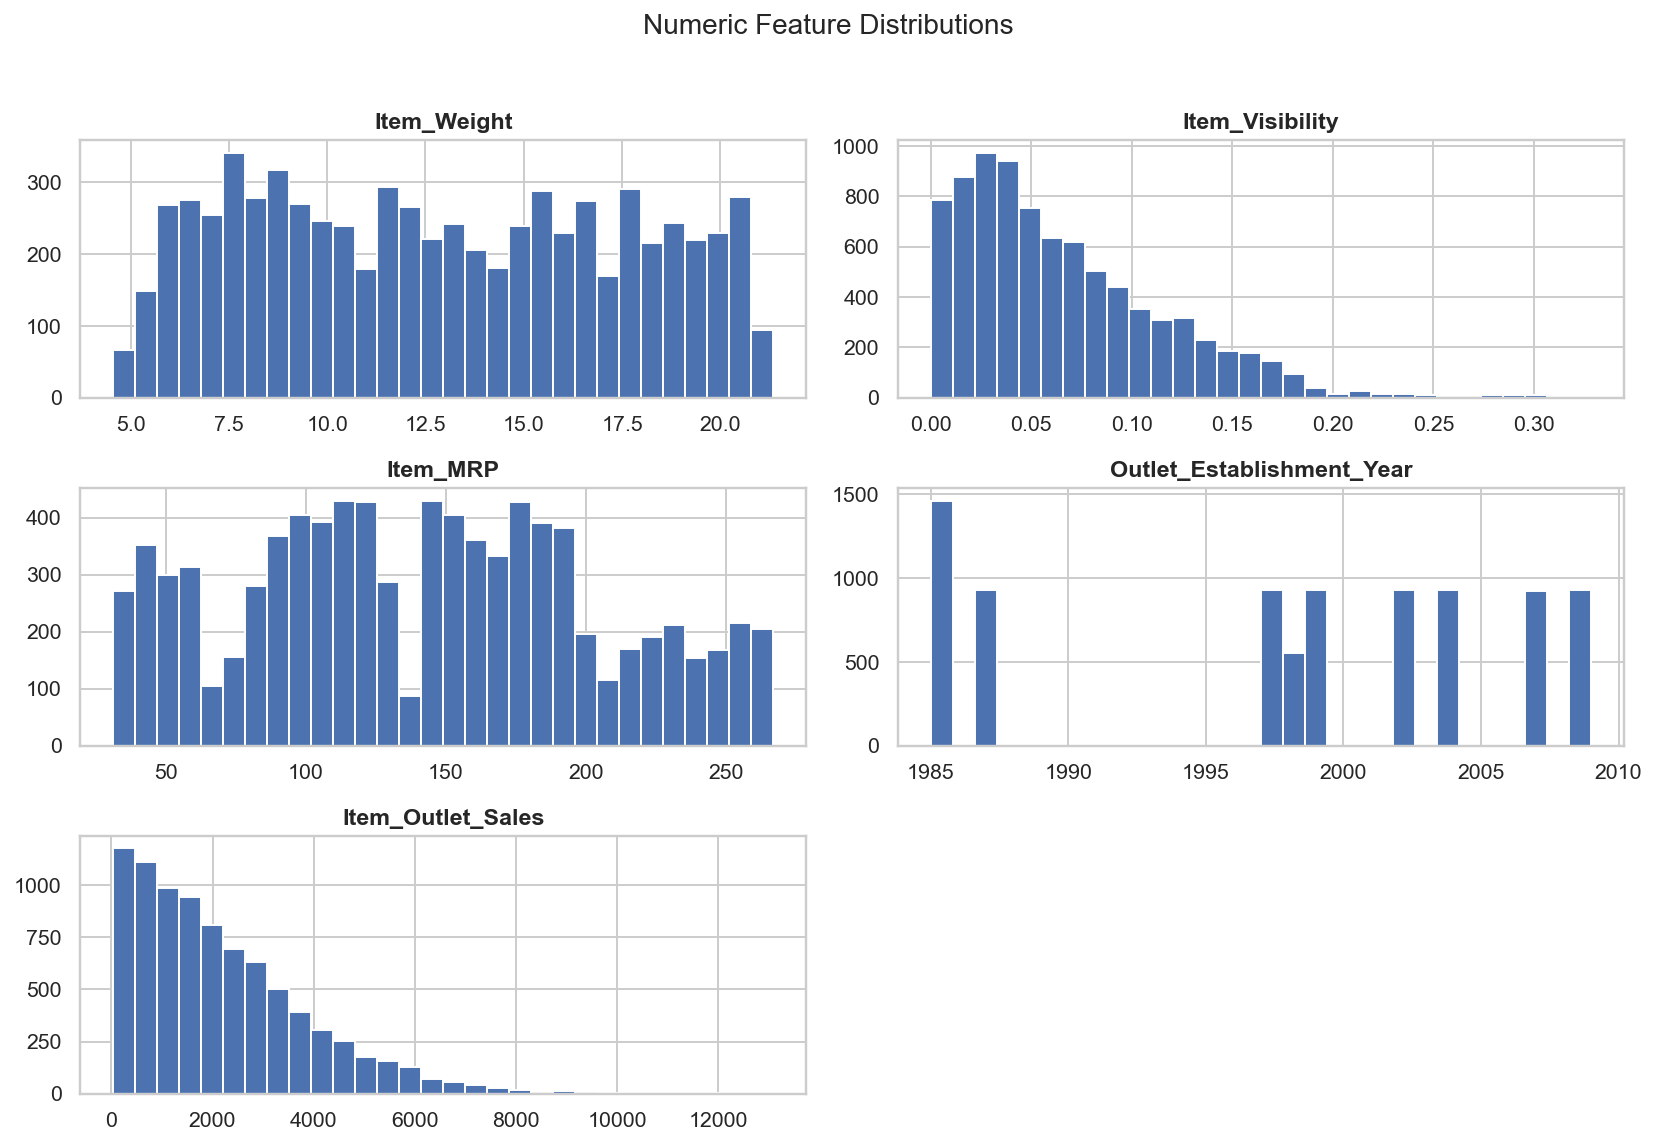

In [7]:
numeric_cols = clean_df.select_dtypes(include="number").columns
clean_df[numeric_cols].hist(figsize=(12, 8), bins=30)
plt.suptitle("Numeric Feature Distributions", y=1.02)
plt.tight_layout()
plt.show()

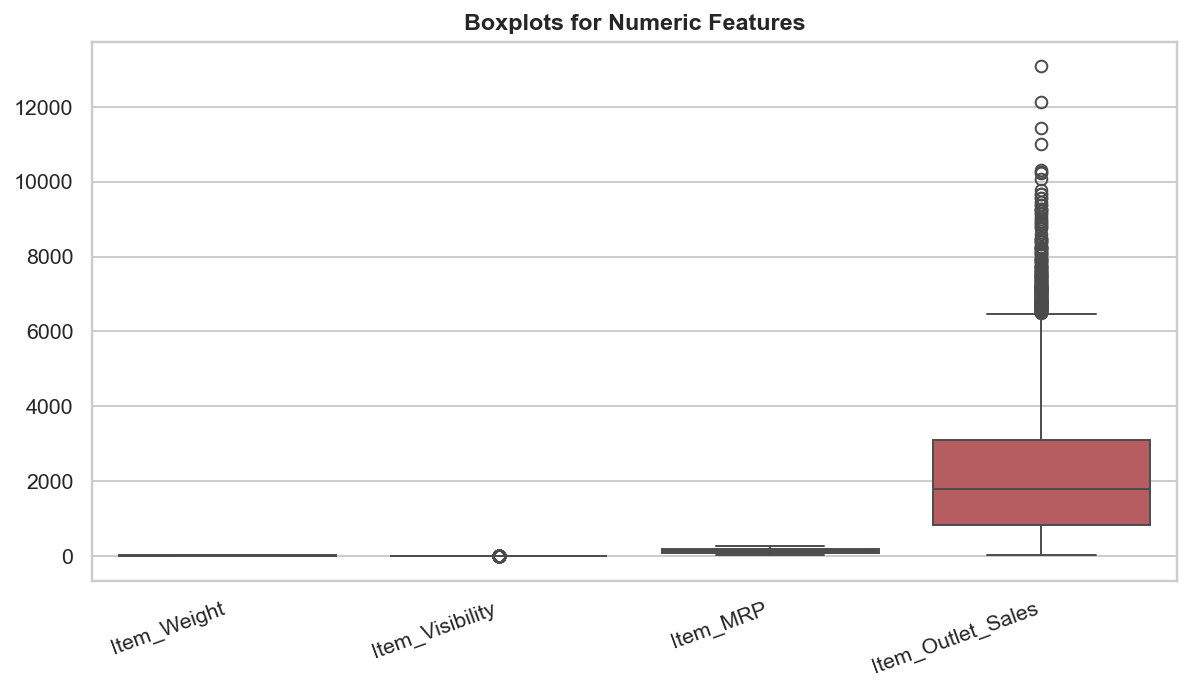

In [8]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=clean_df[["Item_Weight", "Item_Visibility", "Item_MRP", "Item_Outlet_Sales"]])
plt.title("Boxplots for Numeric Features")
plt.xticks(rotation=20, ha="right")
plt.show()

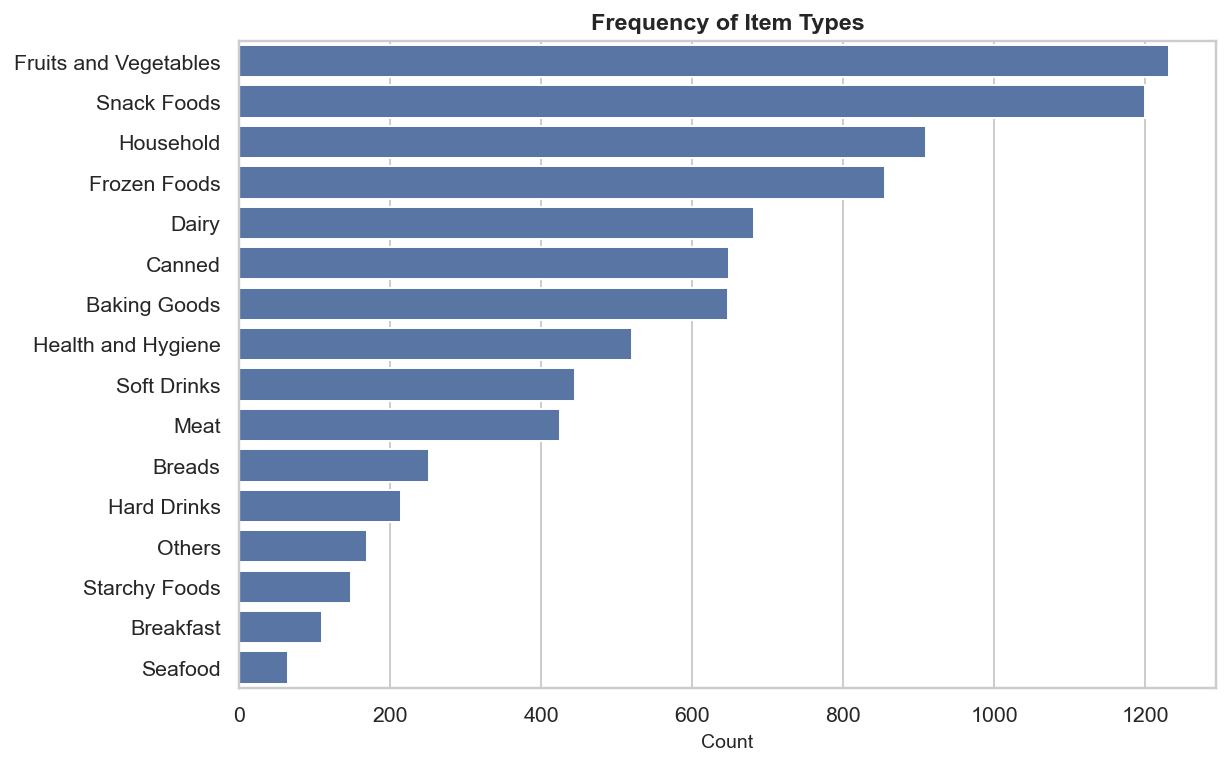

In [9]:
plt.figure(figsize=(9, 6))
sns.countplot(data=clean_df, y="Item_Type", order=clean_df["Item_Type"].value_counts().index)
plt.title("Frequency of Item Types")
plt.xlabel("Count")
plt.ylabel("")
plt.show()

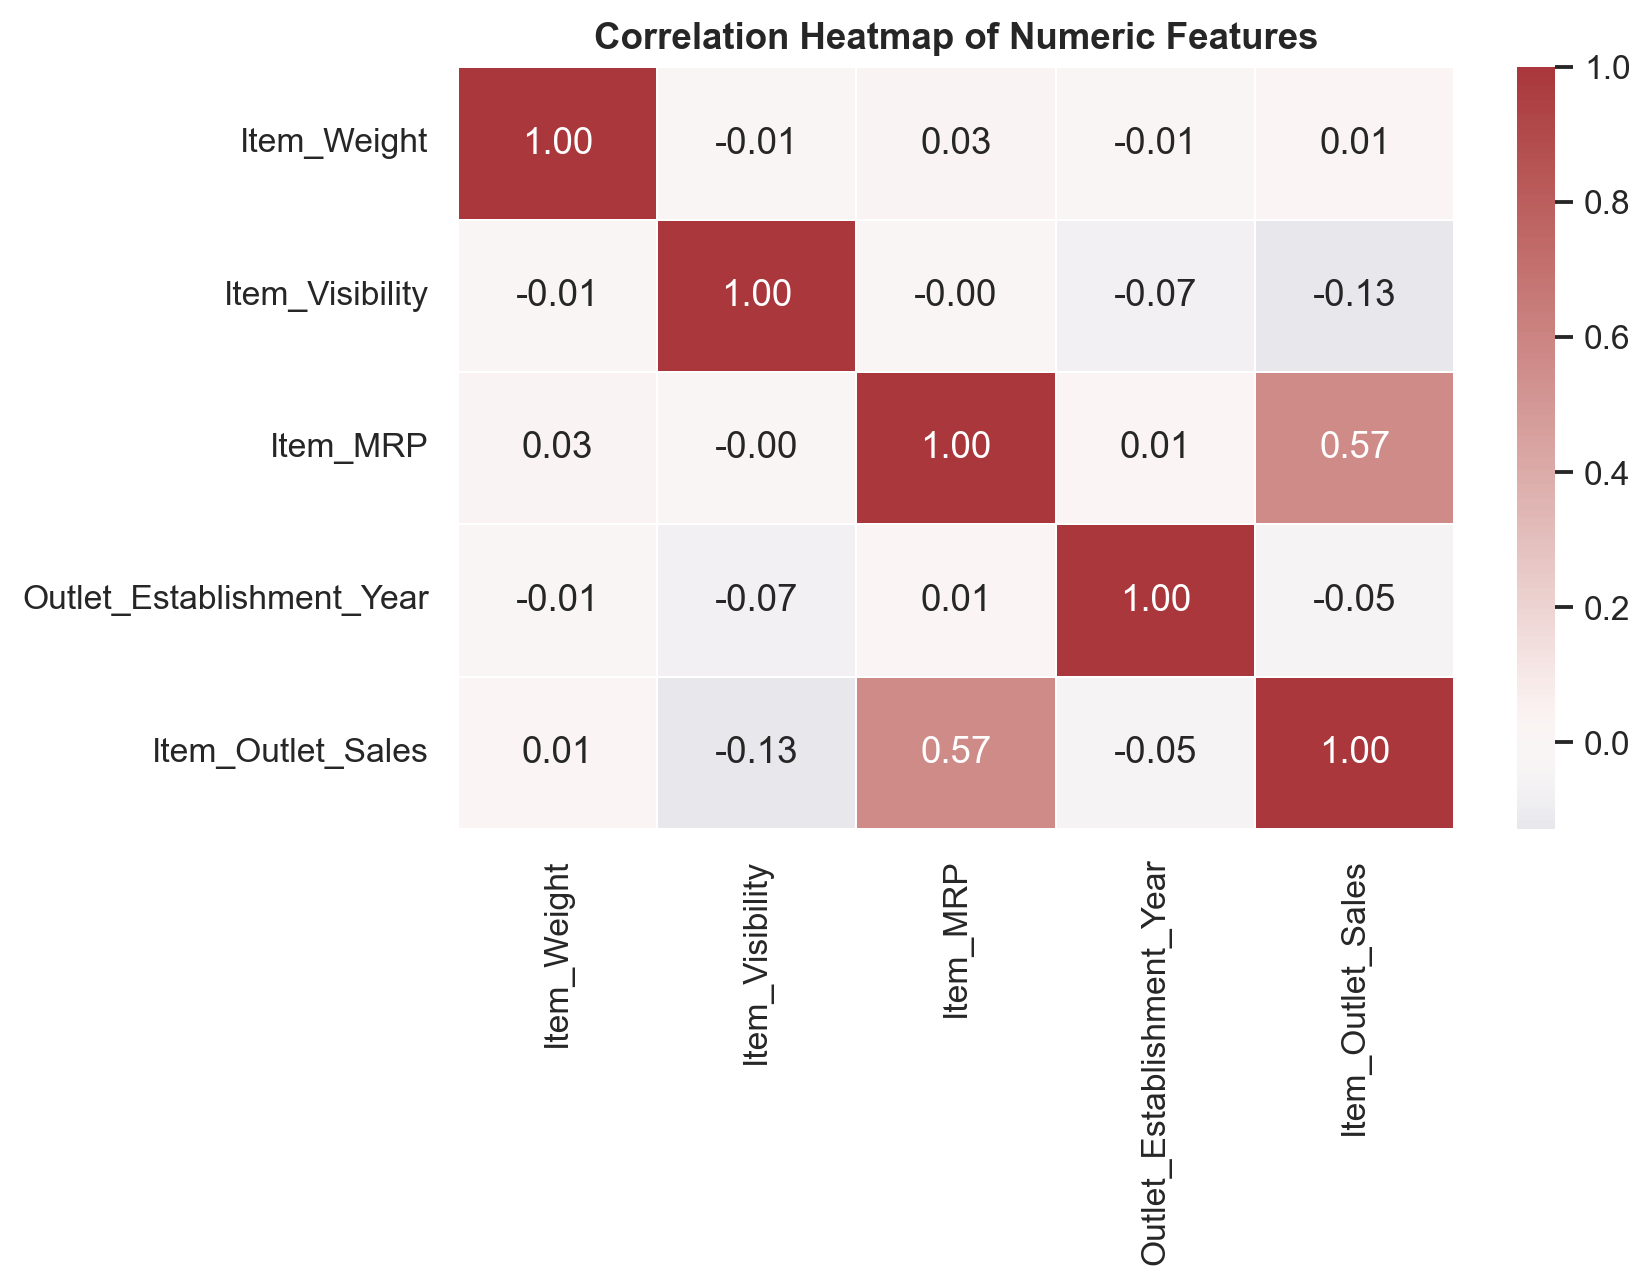

In [10]:
plot_correlation_heatmap(clean_df, FIGURES_DIR / "correlation_heatmap.png")
display(Image(filename=str(FIGURES_DIR / "correlation_heatmap.png")))

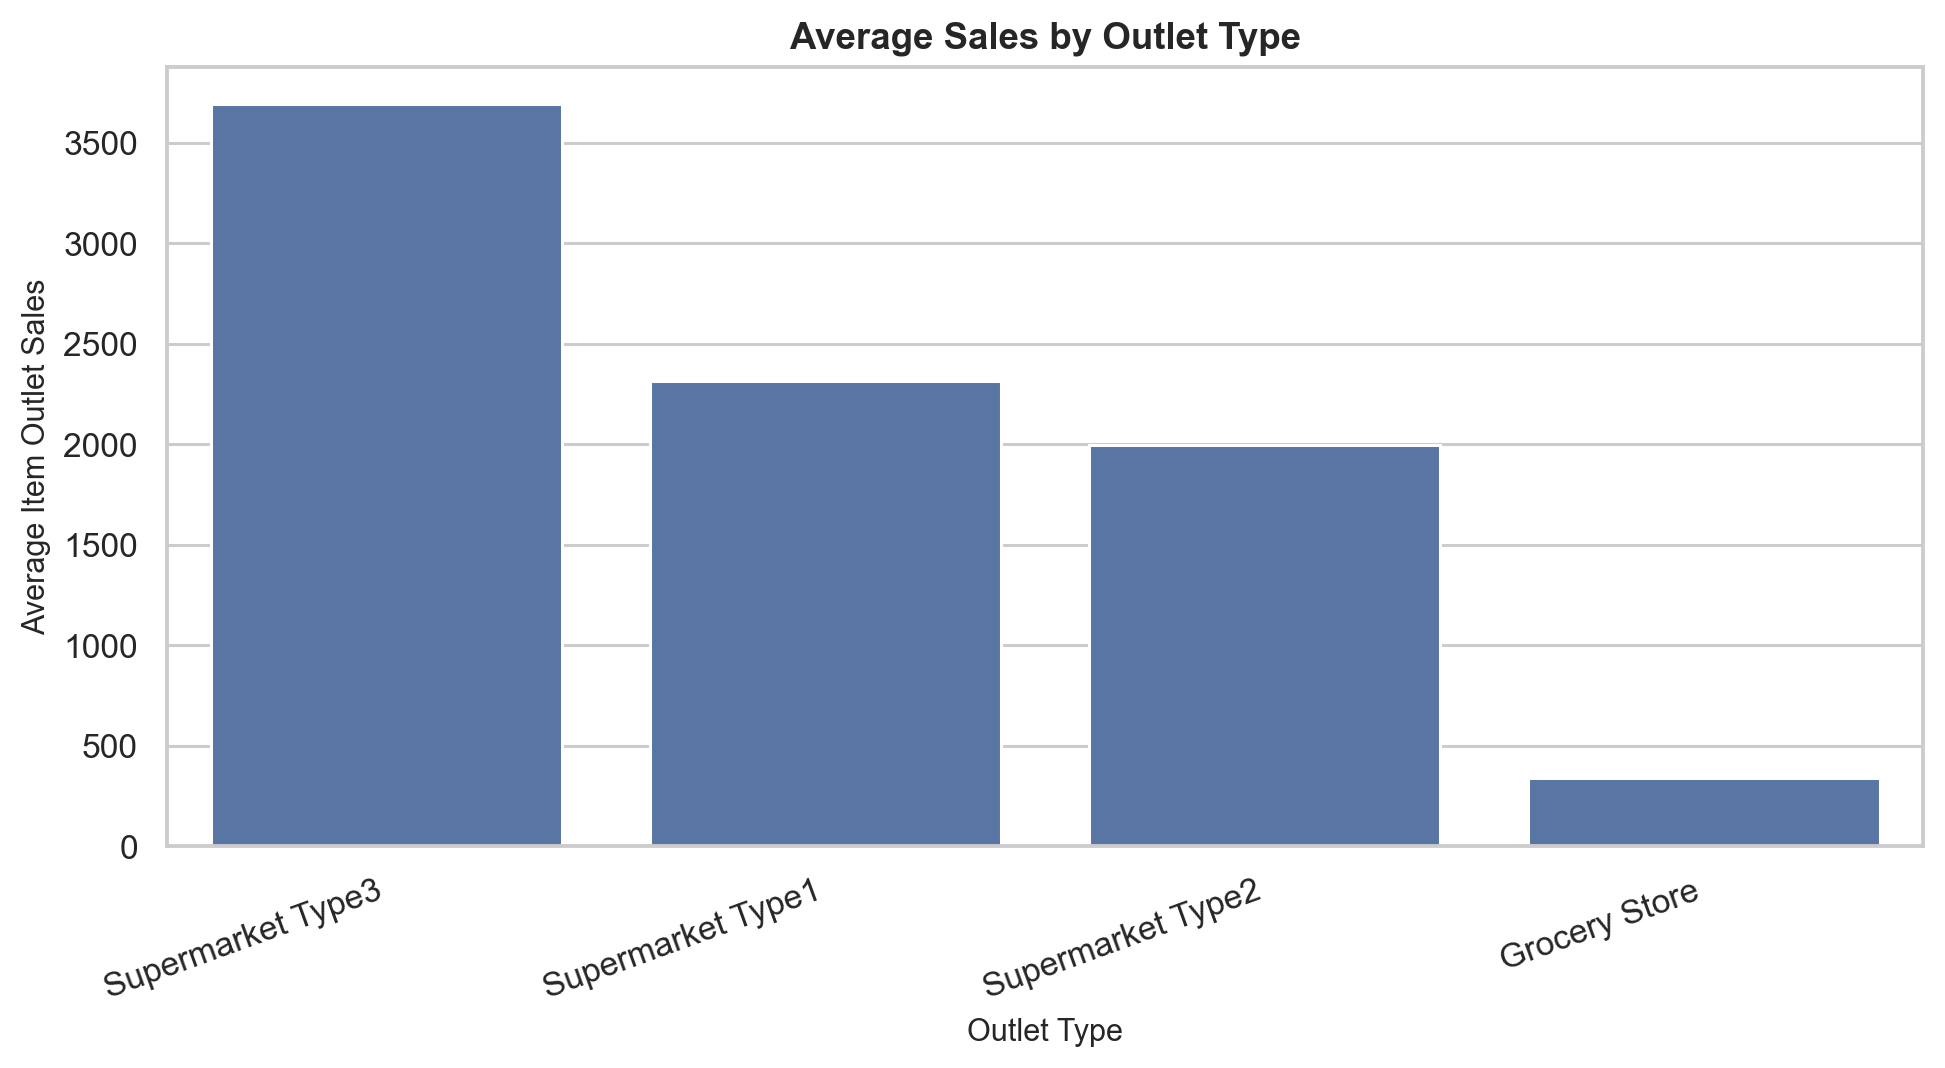

In [11]:
plot_outlet_type_vs_sales(clean_df, FIGURES_DIR / "outlet_type_vs_sales.png")
display(Image(filename=str(FIGURES_DIR / "outlet_type_vs_sales.png")))

## Feature Inspection

The placeholders used for the Part 2 cleaning check are converted back to null values here so feature inspection can report the real missing-value frequency.

In [12]:
feature_inspection_df = restore_placeholders_to_null(placeholder_df)
display(missing_value_report(feature_inspection_df))

,missing_count,missing_percent
Outlet_Size,2410,28.28
Item_Weight,1463,17.17


In [13]:
def plot_univariate_feature(data, feature):
    plt.figure(figsize=(8, 4.5))
    if pd.api.types.is_numeric_dtype(data[feature]):
        sns.histplot(data=data, x=feature, bins=30, kde=True)
        plt.ylabel("Count")
    else:
        order = data[feature].value_counts(dropna=False).head(20).index
        sns.countplot(data=data, y=feature, order=order)
        plt.xlabel("Count")
        plt.ylabel("")
    plt.title(f"Distribution of {feature}")
    plt.tight_layout()
    plt.show()


def plot_feature_vs_target(data, feature, target=TARGET):
    plt.figure(figsize=(8, 4.5))
    if pd.api.types.is_numeric_dtype(data[feature]):
        sns.scatterplot(data=data, x=feature, y=target, alpha=0.35, edgecolor=None)
    else:
        order = (
            data.groupby(feature, dropna=False)[target]
            .mean()
            .sort_values(ascending=False)
            .head(20)
            .index
        )
        sns.barplot(data=data, y=feature, x=target, order=order, errorbar=None)
        plt.ylabel("")
    plt.title(f"{feature} vs. {target}")
    plt.tight_layout()
    plt.show()

### Item_Identifier

Definition: Unique product ID

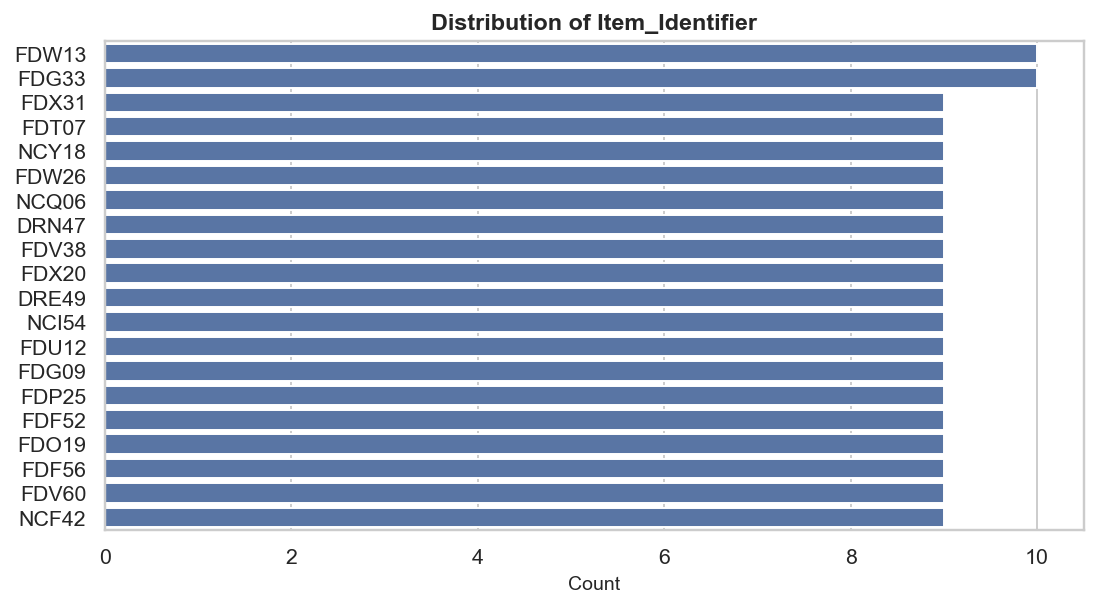

In [14]:
plot_univariate_feature(feature_inspection_df, "Item_Identifier")

Feature inspection notes:

- Type: Categorical (nominal).
- Null values: 0 (0.00%); action: No missing-value action is needed.
- Constant or quasi-constant: not constant or quasi-constant.
- Cardinality: 1,559; high cardinality (>10): Yes.
- Known before target: Yes, this is known before the item sales are measured.
- Business exclusion: Exclude from modeling because it is a high-cardinality identifier.

Predictor notes:

- Business expectation: No; this is a product ID and should not be treated as a general business driver.
- Visual/statistical signal: The raw averages vary by product ID, but this is high-cardinality and not reliable for generalization.

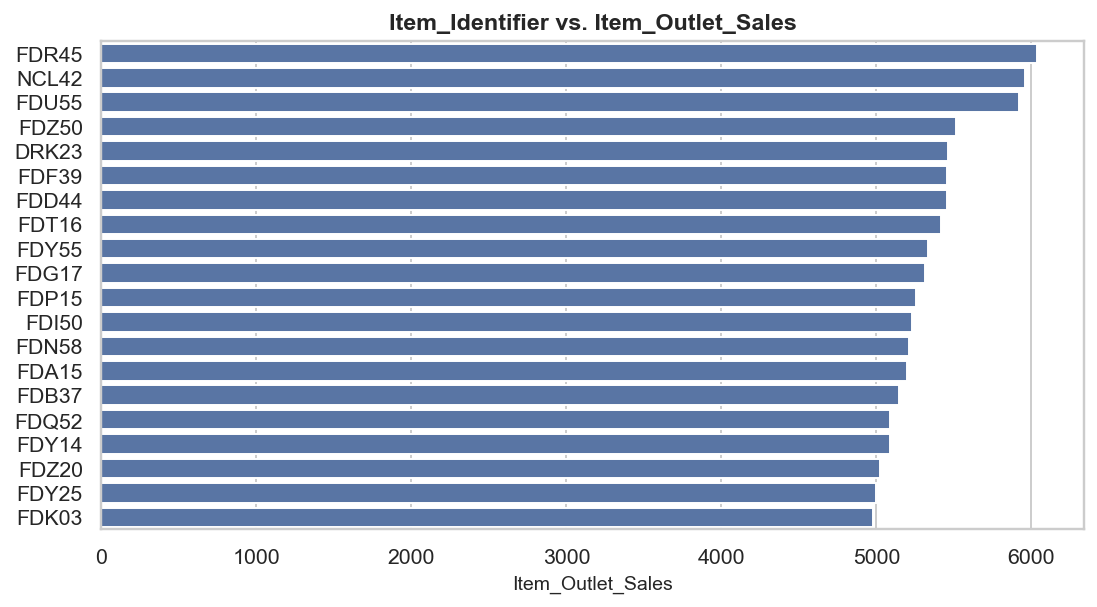

In [15]:
plot_feature_vs_target(feature_inspection_df, "Item_Identifier")

Based on the business context, No; this is a product ID and should not be treated as a general business driver.

Based on the visualization, The raw averages vary by product ID, but this is high-cardinality and not reliable for generalization.

### Item_Weight

Definition: Weight of product

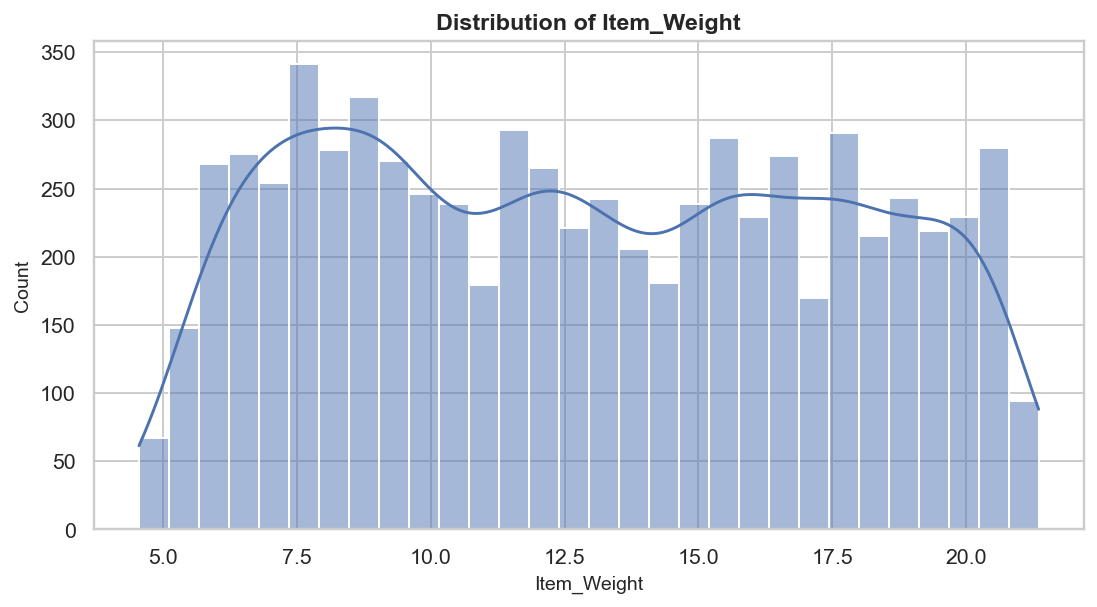

In [16]:
plot_univariate_feature(feature_inspection_df, "Item_Weight")

Feature inspection notes:

- Type: Numeric.
- Null values: 1,463 (17.17%); action: Impute with the median after the train-test split.
- Constant or quasi-constant: not constant or quasi-constant.
- Cardinality: 415; high cardinality (>10): Yes.
- Known before target: Yes, this is known before the item sales are measured.
- Business exclusion: Keep unless model validation shows it hurts generalization.

Predictor notes:

- Business expectation: Only weakly; the business connection is plausible but likely indirect.
- Visual/statistical signal: The correlation with sales is 0.014, which suggests a weak linear signal.

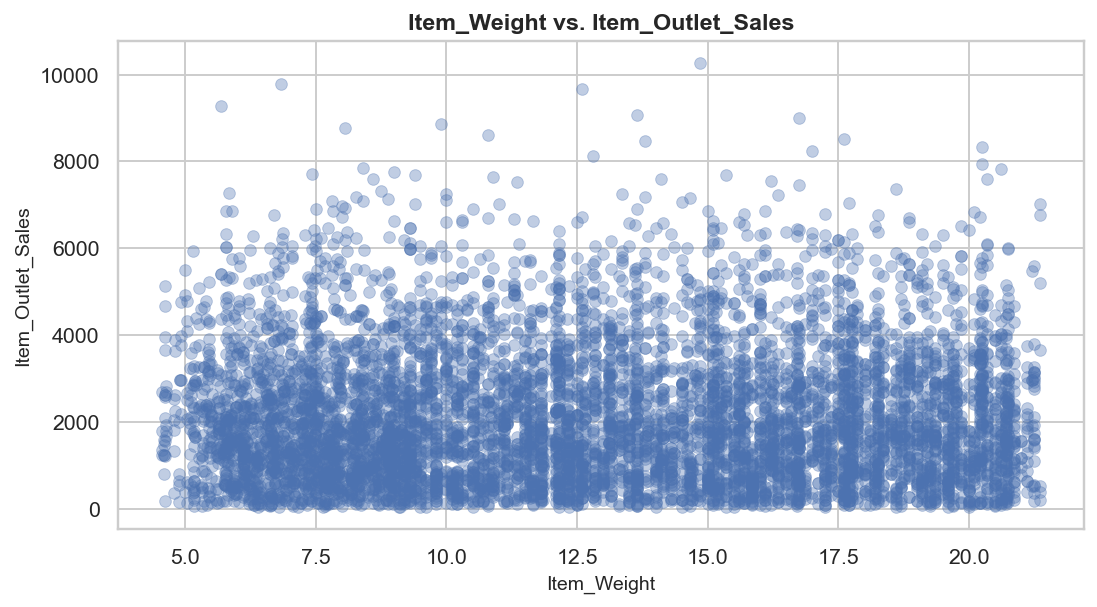

In [17]:
plot_feature_vs_target(feature_inspection_df, "Item_Weight")

Based on the business context, Only weakly; the business connection is plausible but likely indirect.

Based on the visualization, The correlation with sales is 0.014, which suggests a weak linear signal.

### Item_Fat_Content

Definition: Whether the product is low fat or regular

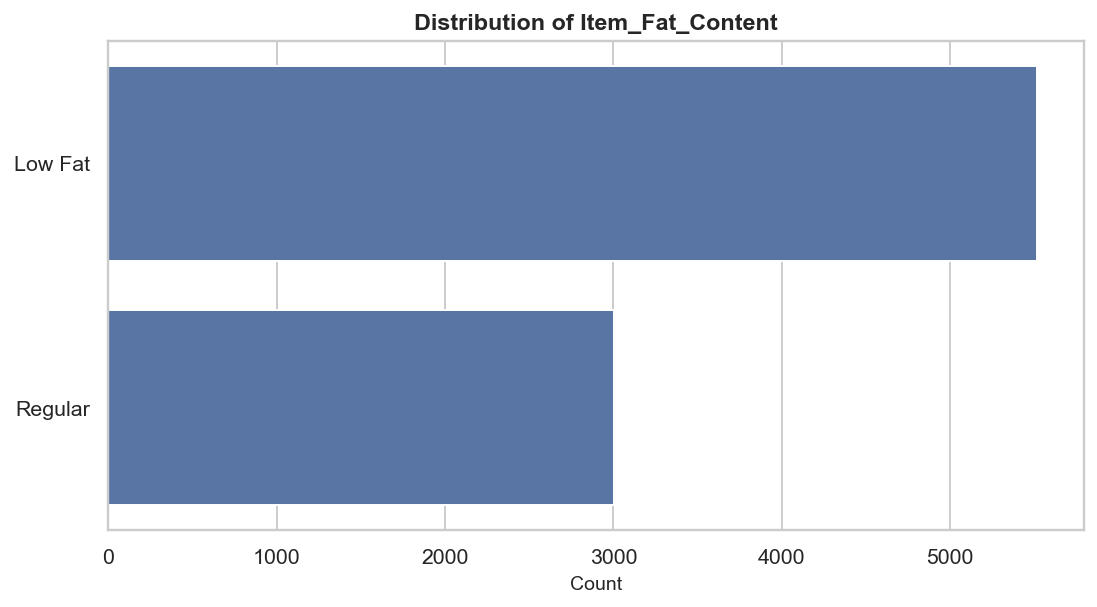

In [18]:
plot_univariate_feature(feature_inspection_df, "Item_Fat_Content")

Feature inspection notes:

- Type: Categorical (nominal).
- Null values: 0 (0.00%); action: No missing-value action is needed.
- Constant or quasi-constant: not constant or quasi-constant.
- Cardinality: 2; high cardinality (>10): No.
- Known before target: Yes, this is known before the item sales are measured.
- Business exclusion: Keep unless model validation shows it hurts generalization.

Predictor notes:

- Business expectation: Only weakly; the business connection is plausible but likely indirect.
- Visual/statistical signal: Average sales vary by about 3.1% of the overall mean across categories, suggesting a weak signal.

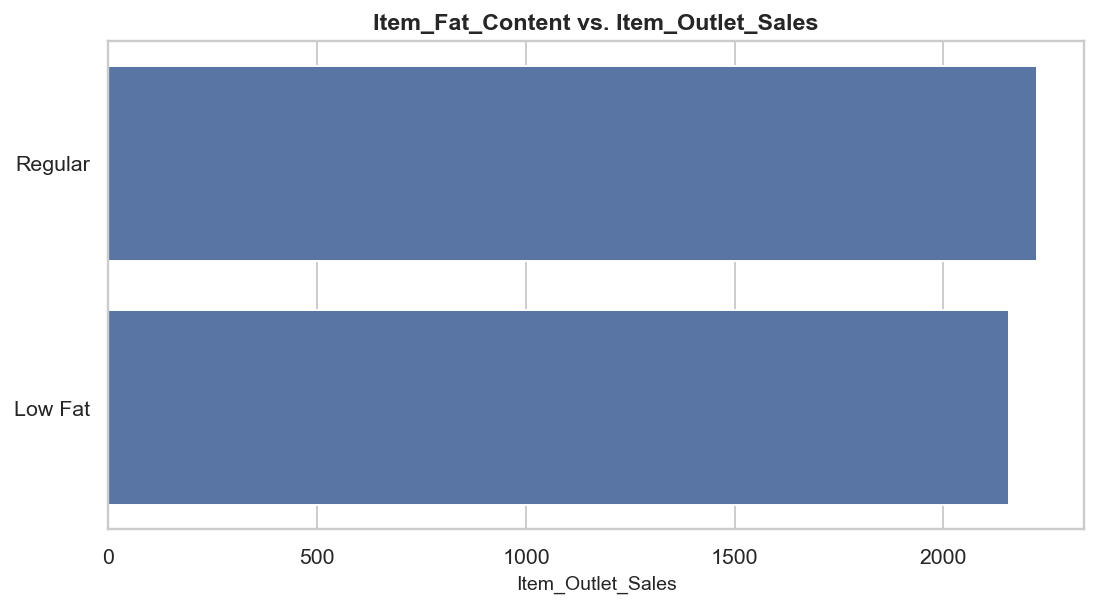

In [19]:
plot_feature_vs_target(feature_inspection_df, "Item_Fat_Content")

Based on the business context, Only weakly; the business connection is plausible but likely indirect.

Based on the visualization, Average sales vary by about 3.1% of the overall mean across categories, suggesting a weak signal.

### Item_Visibility

Definition: The percentage of total display area of all products in a store allocated to the particular product

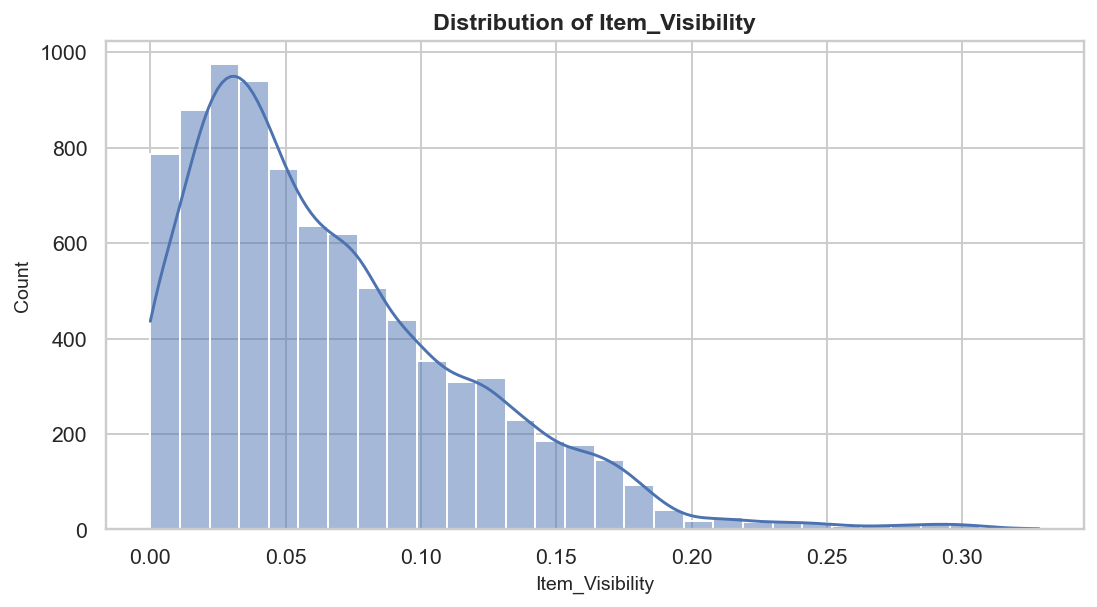

In [20]:
plot_univariate_feature(feature_inspection_df, "Item_Visibility")

Feature inspection notes:

- Type: Numeric.
- Null values: 0 (0.00%); action: No missing-value action is needed.
- Constant or quasi-constant: not constant or quasi-constant.
- Cardinality: 7,880; high cardinality (>10): Yes.
- Known before target: Yes, this is known before the item sales are measured.
- Business exclusion: Keep unless model validation shows it hurts generalization.

Predictor notes:

- Business expectation: Possibly; it may capture store or product context that affects demand.
- Visual/statistical signal: The correlation with sales is -0.129, which suggests a moderate linear signal.

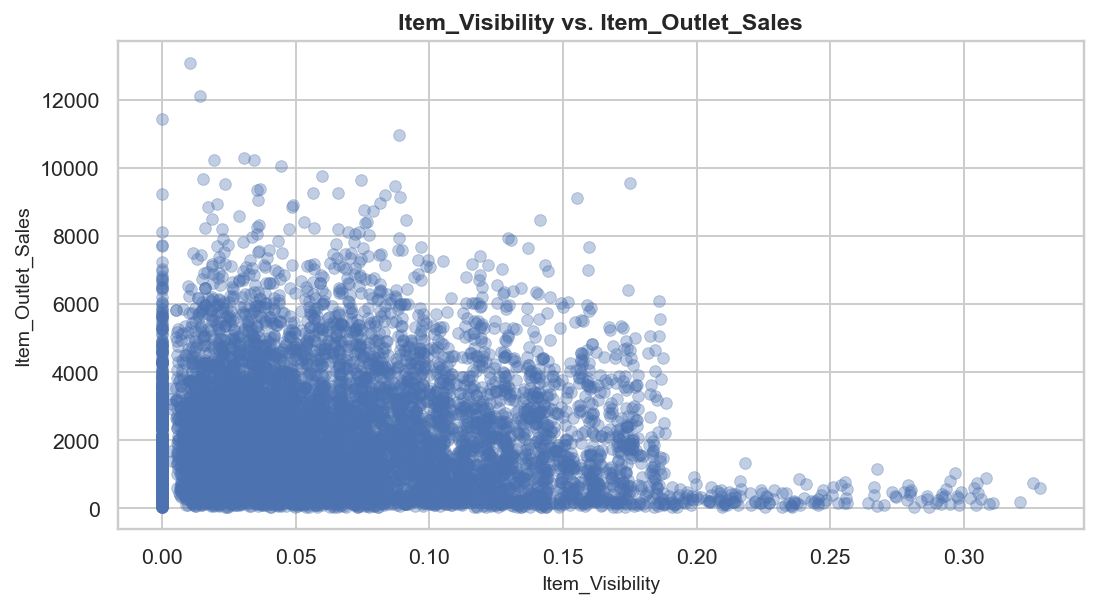

In [21]:
plot_feature_vs_target(feature_inspection_df, "Item_Visibility")

Based on the business context, Possibly; it may capture store or product context that affects demand.

Based on the visualization, The correlation with sales is -0.129, which suggests a moderate linear signal.

### Item_Type

Definition: The category to which the product belongs

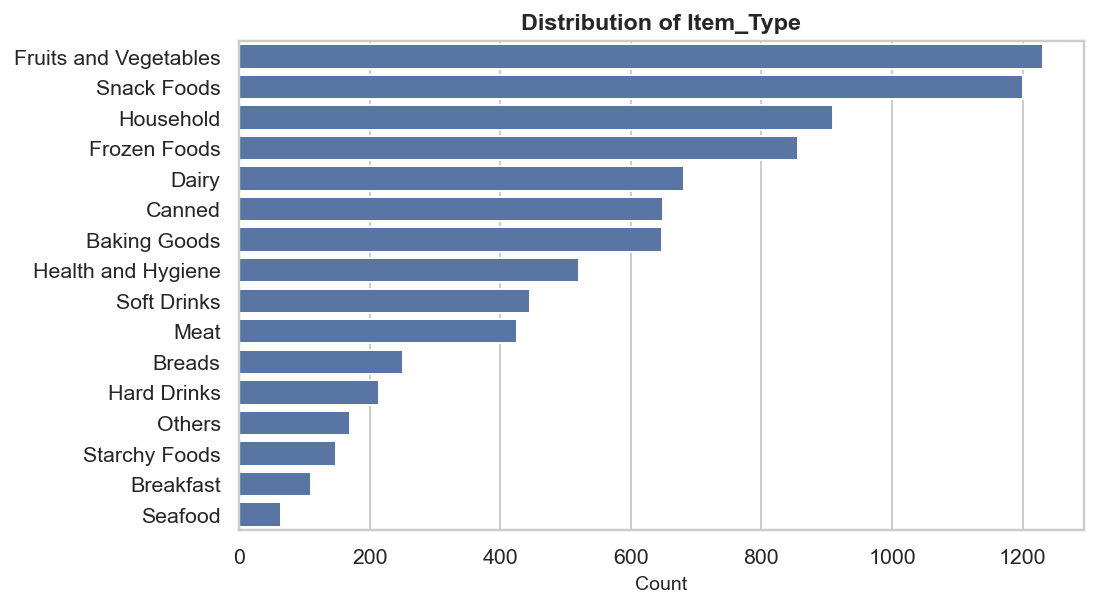

In [22]:
plot_univariate_feature(feature_inspection_df, "Item_Type")

Feature inspection notes:

- Type: Categorical (nominal).
- Null values: 0 (0.00%); action: No missing-value action is needed.
- Constant or quasi-constant: not constant or quasi-constant.
- Cardinality: 16; high cardinality (>10): Yes.
- Known before target: Yes, this is known before the item sales are measured.
- Business exclusion: Keep unless model validation shows it hurts generalization.

Predictor notes:

- Business expectation: Possibly; it may capture store or product context that affects demand.
- Visual/statistical signal: Average sales vary by about 20.5% of the overall mean across categories, suggesting a moderate signal.

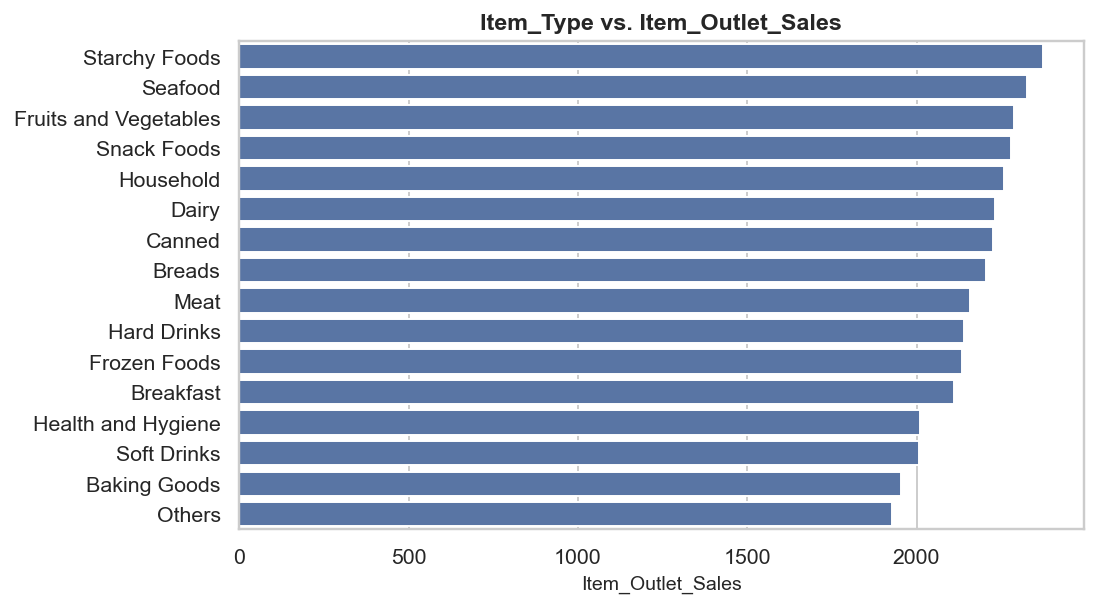

In [23]:
plot_feature_vs_target(feature_inspection_df, "Item_Type")

Based on the business context, Possibly; it may capture store or product context that affects demand.

Based on the visualization, Average sales vary by about 20.5% of the overall mean across categories, suggesting a moderate signal.

### Item_MRP

Definition: Maximum Retail Price (list price) of the product

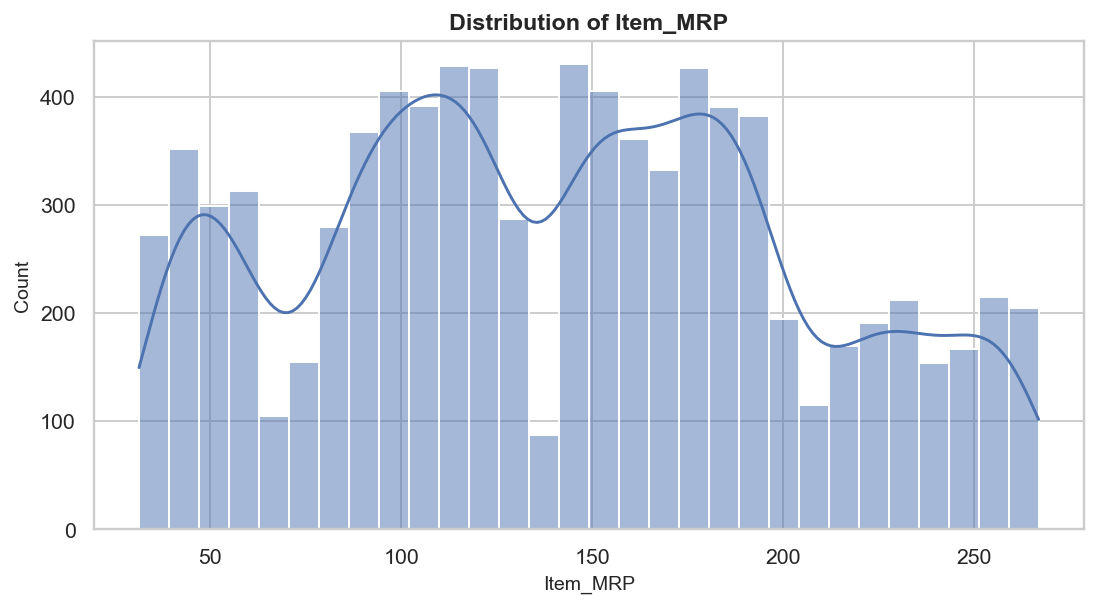

In [24]:
plot_univariate_feature(feature_inspection_df, "Item_MRP")

Feature inspection notes:

- Type: Numeric.
- Null values: 0 (0.00%); action: No missing-value action is needed.
- Constant or quasi-constant: not constant or quasi-constant.
- Cardinality: 5,938; high cardinality (>10): Yes.
- Known before target: Yes, this is known before the item sales are measured.
- Business exclusion: Keep unless model validation shows it hurts generalization.

Predictor notes:

- Business expectation: Yes; this feature has a clear business relationship to sales.
- Visual/statistical signal: The correlation with sales is 0.568, which suggests a strong linear signal.

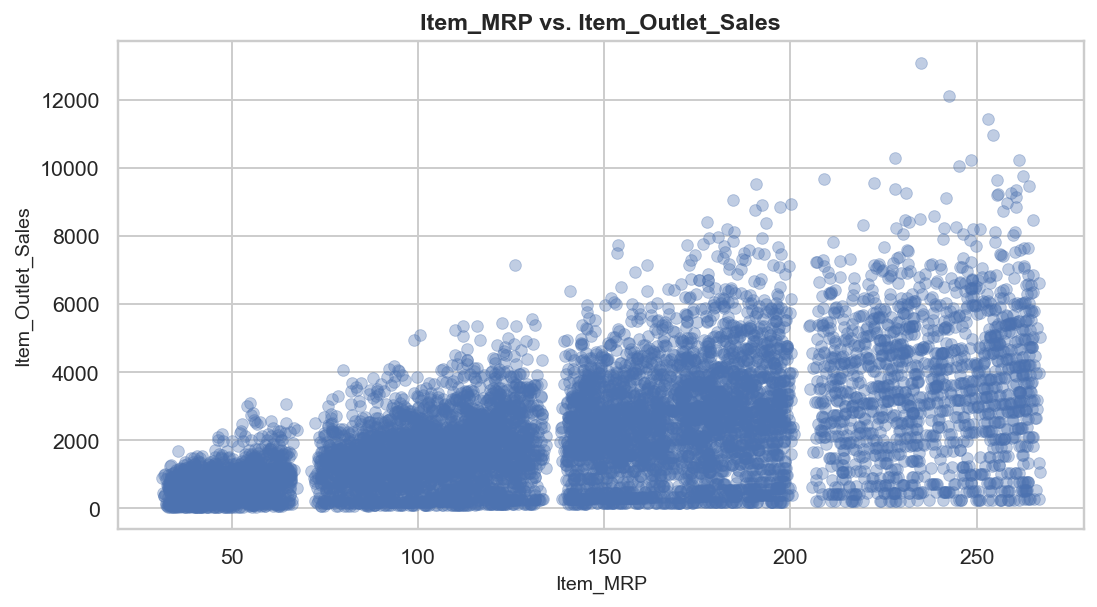

In [25]:
plot_feature_vs_target(feature_inspection_df, "Item_MRP")

Based on the business context, Yes; this feature has a clear business relationship to sales.

Based on the visualization, The correlation with sales is 0.568, which suggests a strong linear signal.

### Outlet_Identifier

Definition: Unique store ID

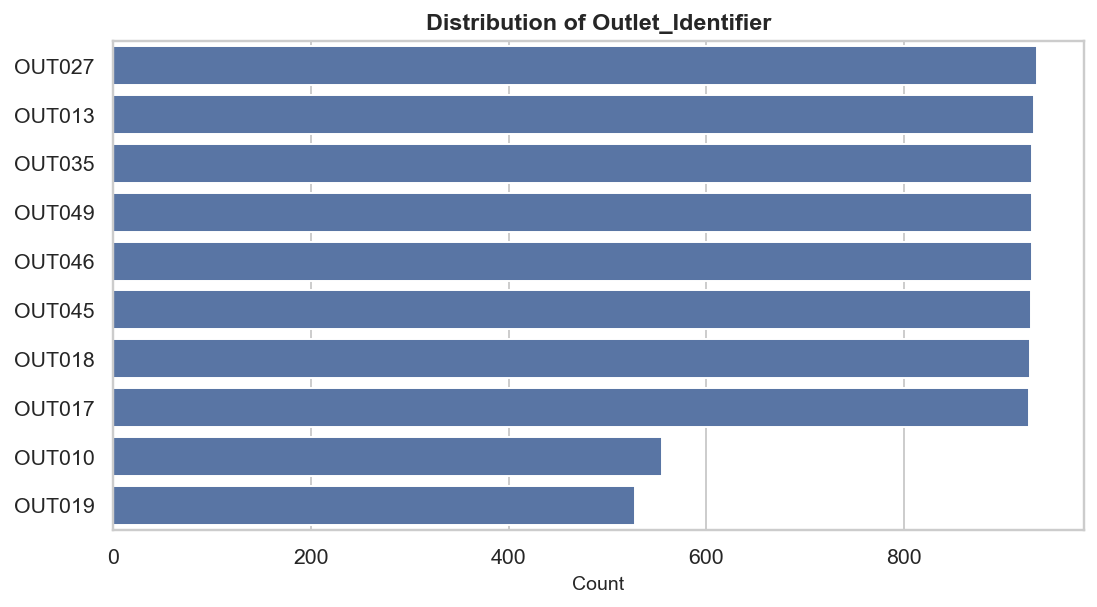

In [26]:
plot_univariate_feature(feature_inspection_df, "Outlet_Identifier")

Feature inspection notes:

- Type: Categorical (nominal).
- Null values: 0 (0.00%); action: No missing-value action is needed.
- Constant or quasi-constant: not constant or quasi-constant.
- Cardinality: 10; high cardinality (>10): No.
- Known before target: Yes, this is known before the item sales are measured.
- Business exclusion: Keep unless model validation shows it hurts generalization.

Predictor notes:

- Business expectation: Possibly; it may capture store or product context that affects demand.
- Visual/statistical signal: Average sales vary by about 153.8% of the overall mean across categories, suggesting a strong signal.

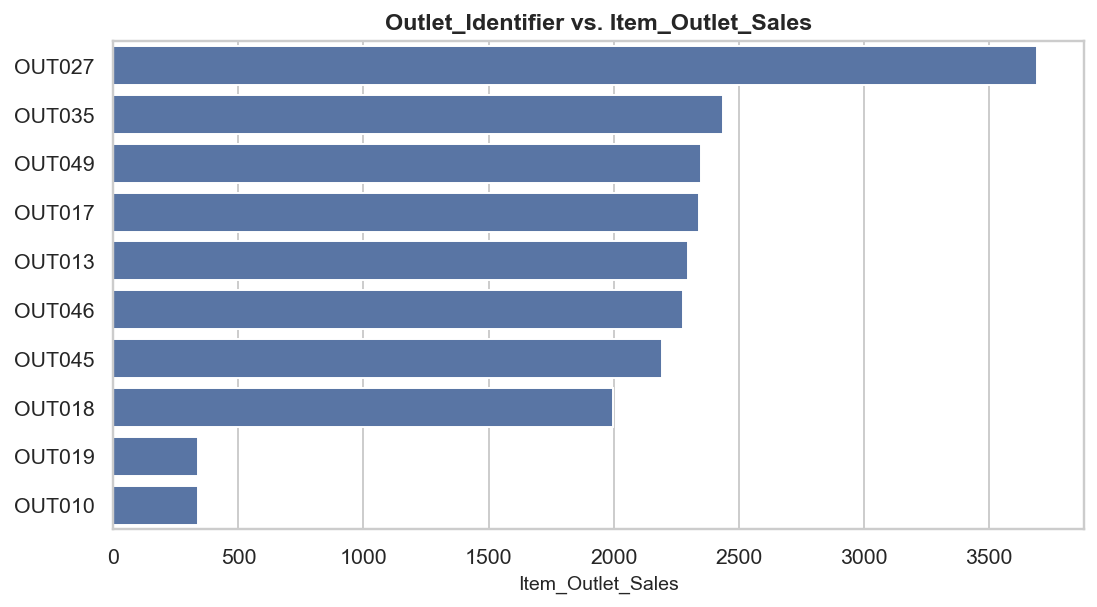

In [27]:
plot_feature_vs_target(feature_inspection_df, "Outlet_Identifier")

Based on the business context, Possibly; it may capture store or product context that affects demand.

Based on the visualization, Average sales vary by about 153.8% of the overall mean across categories, suggesting a strong signal.

### Outlet_Establishment_Year

Definition: The year in which store was established

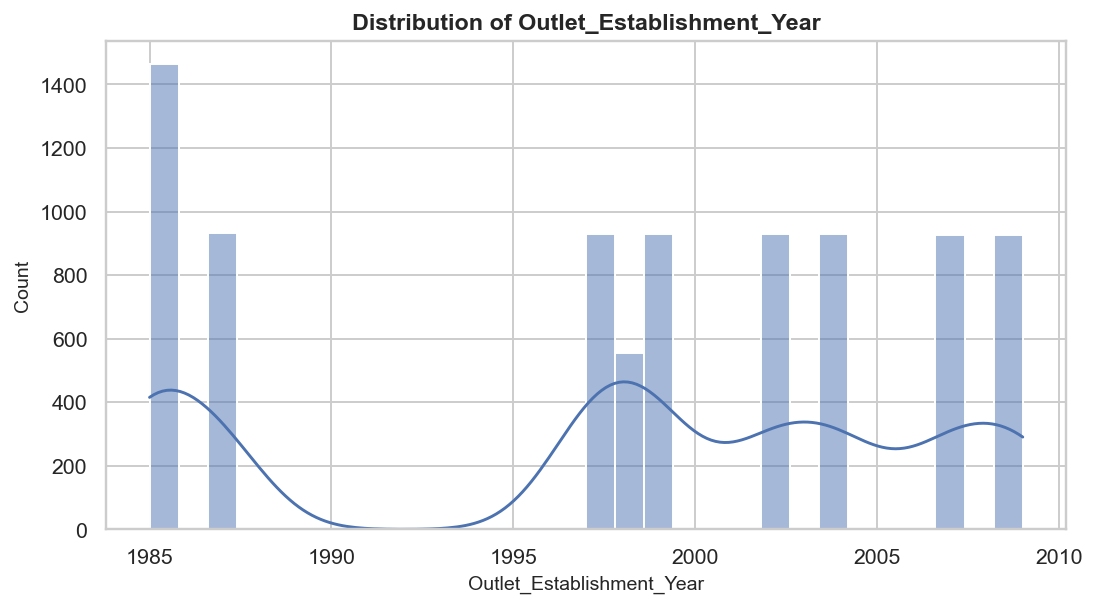

In [28]:
plot_univariate_feature(feature_inspection_df, "Outlet_Establishment_Year")

Feature inspection notes:

- Type: Numeric.
- Null values: 0 (0.00%); action: No missing-value action is needed.
- Constant or quasi-constant: not constant or quasi-constant.
- Cardinality: 9; high cardinality (>10): No.
- Known before target: Yes, this is known before the item sales are measured.
- Business exclusion: Keep unless model validation shows it hurts generalization.

Predictor notes:

- Business expectation: Possibly; it may capture store or product context that affects demand.
- Visual/statistical signal: The correlation with sales is -0.049, which suggests a weak linear signal.

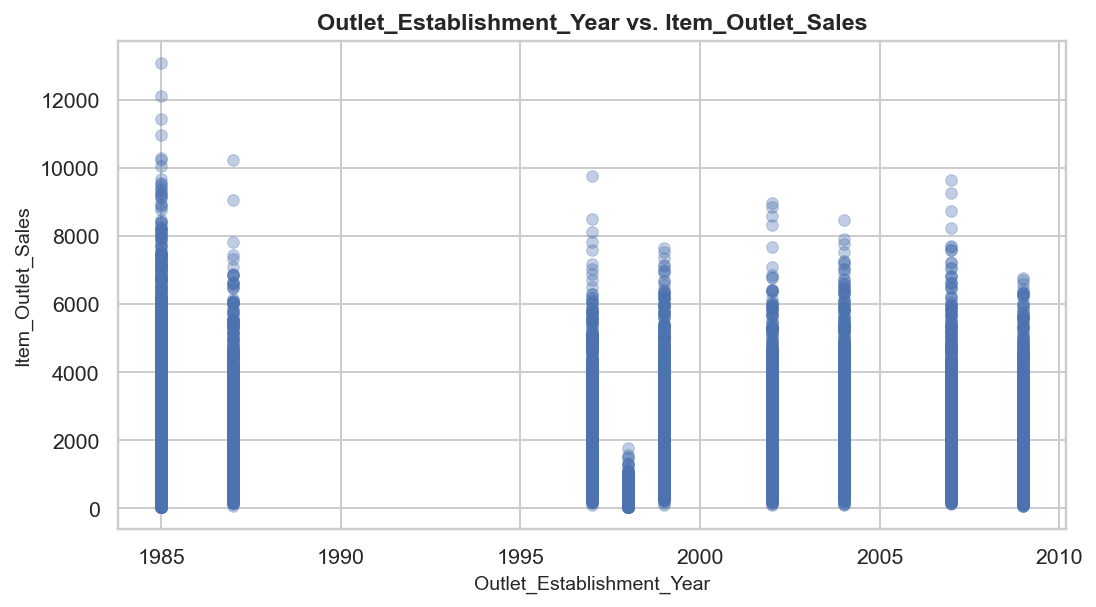

In [29]:
plot_feature_vs_target(feature_inspection_df, "Outlet_Establishment_Year")

Based on the business context, Possibly; it may capture store or product context that affects demand.

Based on the visualization, The correlation with sales is -0.049, which suggests a weak linear signal.

### Outlet_Size

Definition: The size of the store in terms of ground area covered

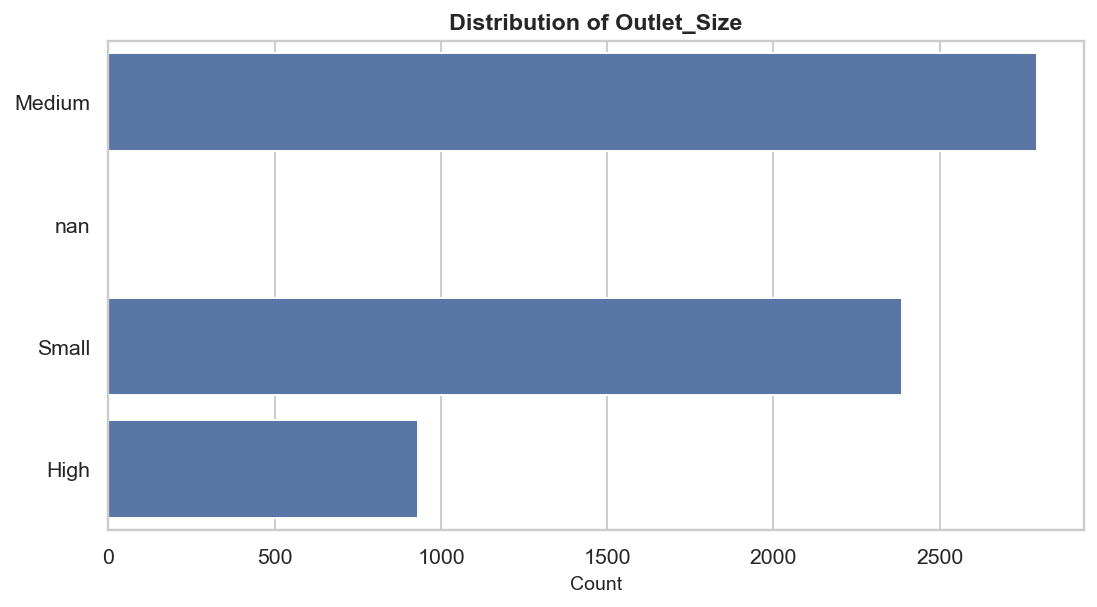

In [30]:
plot_univariate_feature(feature_inspection_df, "Outlet_Size")

Feature inspection notes:

- Type: Ordinal categorical.
- Null values: 2,410 (28.28%); action: Impute with the most frequent category after the train-test split.
- Constant or quasi-constant: not constant or quasi-constant.
- Cardinality: 3; high cardinality (>10): No.
- Known before target: Yes, this is known before the item sales are measured.
- Business exclusion: Keep unless model validation shows it hurts generalization.

Predictor notes:

- Business expectation: Yes; this feature has a clear business relationship to sales.
- Visual/statistical signal: Average sales vary by about 39.4% of the overall mean across categories, suggesting a moderate signal.

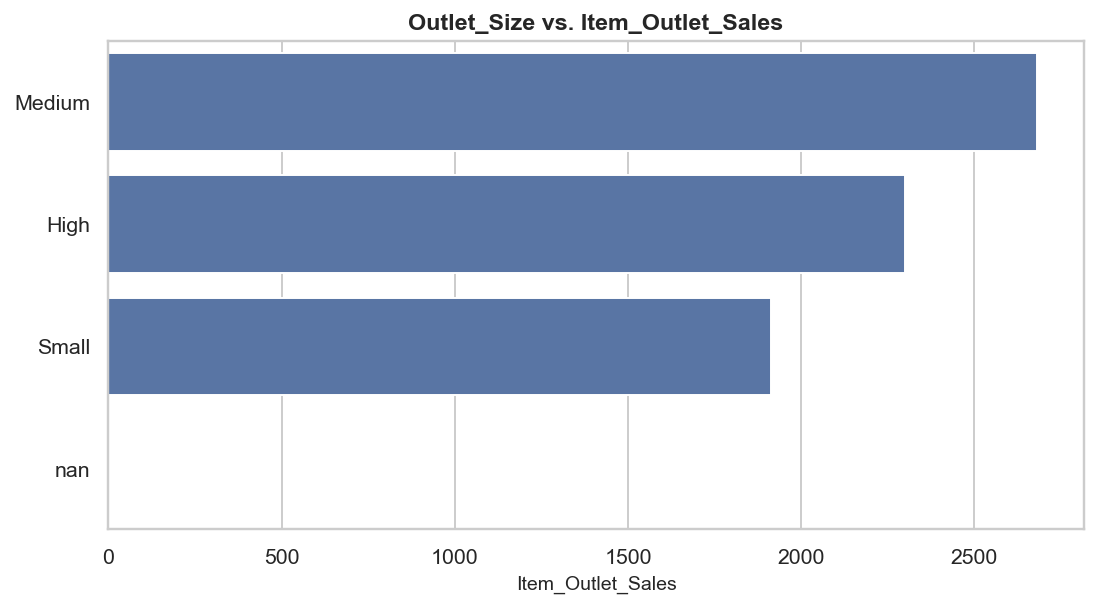

In [31]:
plot_feature_vs_target(feature_inspection_df, "Outlet_Size")

Based on the business context, Yes; this feature has a clear business relationship to sales.

Based on the visualization, Average sales vary by about 39.4% of the overall mean across categories, suggesting a moderate signal.

### Outlet_Location_Type

Definition: The type of area in which the store is located

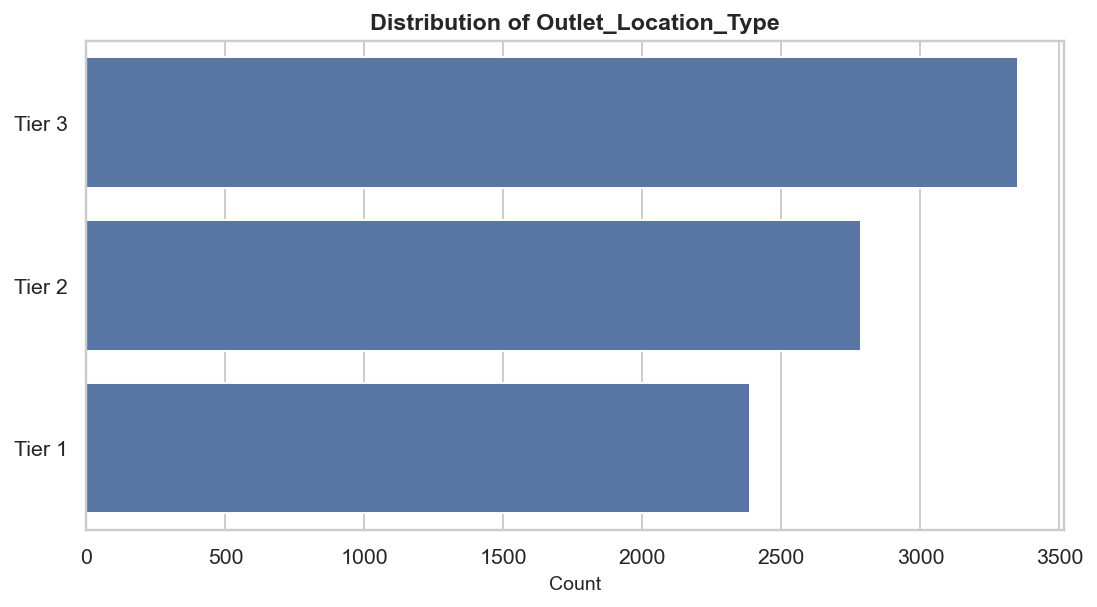

In [32]:
plot_univariate_feature(feature_inspection_df, "Outlet_Location_Type")

Feature inspection notes:

- Type: Ordinal categorical.
- Null values: 0 (0.00%); action: No missing-value action is needed.
- Constant or quasi-constant: not constant or quasi-constant.
- Cardinality: 3; high cardinality (>10): No.
- Known before target: Yes, this is known before the item sales are measured.
- Business exclusion: Keep unless model validation shows it hurts generalization.

Predictor notes:

- Business expectation: Yes; this feature has a clear business relationship to sales.
- Visual/statistical signal: Average sales vary by about 20.5% of the overall mean across categories, suggesting a moderate signal.

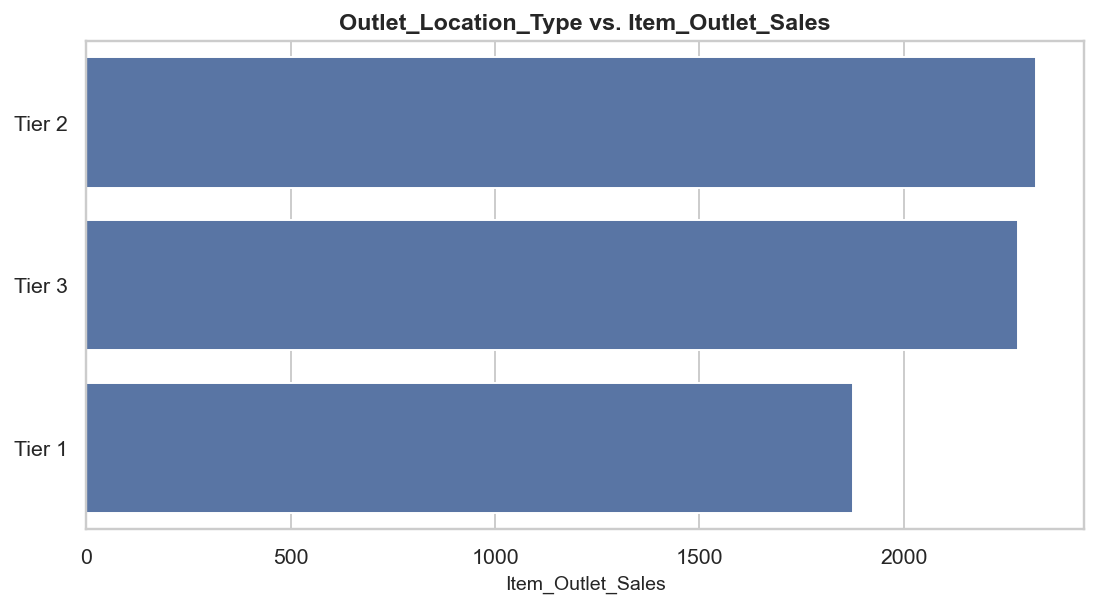

In [33]:
plot_feature_vs_target(feature_inspection_df, "Outlet_Location_Type")

Based on the business context, Yes; this feature has a clear business relationship to sales.

Based on the visualization, Average sales vary by about 20.5% of the overall mean across categories, suggesting a moderate signal.

### Outlet_Type

Definition: Whether the outlet is a grocery store or some sort of supermarket

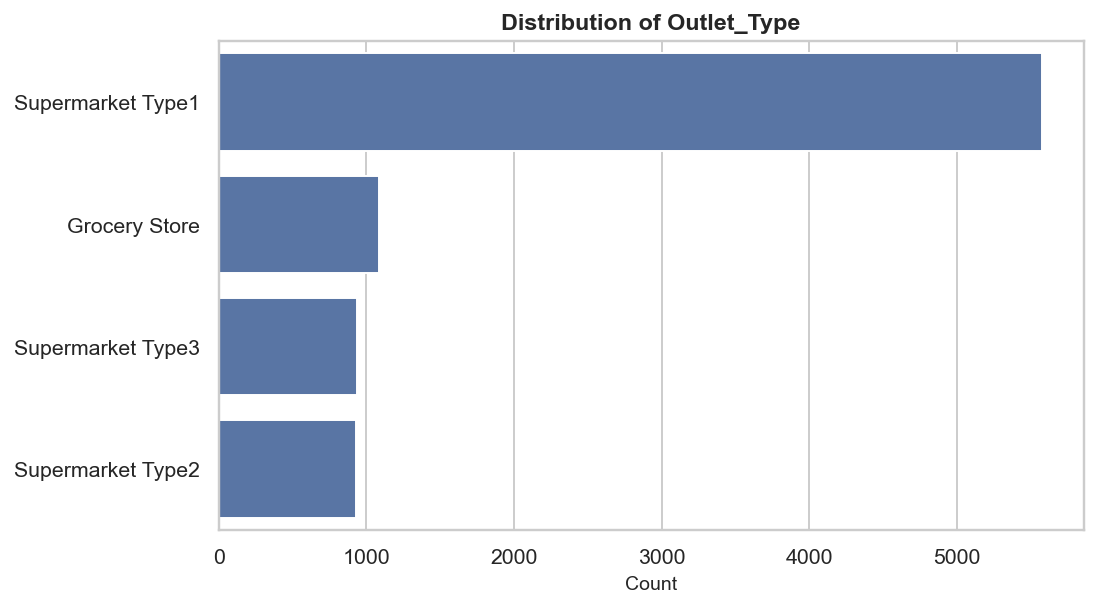

In [34]:
plot_univariate_feature(feature_inspection_df, "Outlet_Type")

Feature inspection notes:

- Type: Categorical (nominal).
- Null values: 0 (0.00%); action: No missing-value action is needed.
- Constant or quasi-constant: not constant or quasi-constant.
- Cardinality: 4; high cardinality (>10): No.
- Known before target: Yes, this is known before the item sales are measured.
- Business exclusion: Keep unless model validation shows it hurts generalization.

Predictor notes:

- Business expectation: Yes; this feature has a clear business relationship to sales.
- Visual/statistical signal: Average sales vary by about 153.8% of the overall mean across categories, suggesting a strong signal.

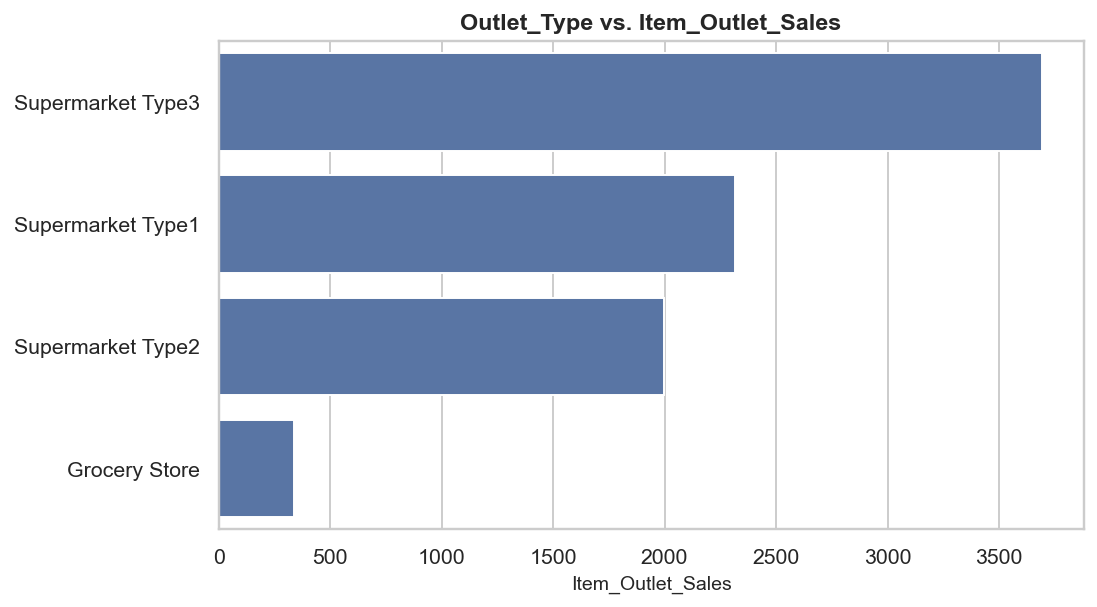

In [35]:
plot_feature_vs_target(feature_inspection_df, "Outlet_Type")

Based on the business context, Yes; this feature has a clear business relationship to sales.

Based on the visualization, Average sales vary by about 153.8% of the overall mean across categories, suggesting a strong signal.